# Chain

## Review

We built a simple graph with nodes, normal edges, and conditional edges.

## Goals

Now, let's build up to a simple chain that combines 4 concepts.

* Using [chat messages](https://docs.langchain.com/oss/python/langchain/messages) as our graph state
* Using [chat models](https://docs.langchain.com/oss/python/integrations/chat) in graph nodes
* [Binding tools](https://docs.langchain.com/oss/python/langchain/models#tool-calling) to our chat model
* [Executing tool calls](https://docs.langchain.com/oss/python/langchain/models#tool-execution-loop) in graph nodes 

![Screenshot 2024-08-21 at 9.24.03 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dd607b08df5e1101_chain1.png)

## Messages

Chat models can use [messages](https://docs.langchain.com/oss/python/langchain/messages), which capture different roles within a conversation. 

LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`. 

These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call. 

Let's create a list of messages. 

Each message can be supplied with a few things:

* `content` - content of the message
* `name` - optionally, a message author 
* `response_metadata` - optionally, a dict of metadata (e.g., often populated by model provider for `AIMessages`)

In [1]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


## Chat Models

Chat models use a sequence of messages as input and support message types, as discussed above.

There are [many](https://docs.langchain.com/oss/python/integrations/chat) to choose from! Let's work with OpenAI. 

Let's check that your `OPENAI_API_KEY` is set and, if not, you will be asked to enter it.

In [2]:
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

True

In [3]:
from langchain.chat_models import init_chat_model

# 1. Initialize Groq
llm = init_chat_model(
    model="openai/gpt-oss-120b", 
    model_provider="groq"
)

# 2. Invoke
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [4]:
result

AIMessage(content='## The\u202fBest\u202fU.S.\u202fSpot(s) to See\u202fOrcas (Killer Whales)\n\n| Rank | Location (State) | Why It’s\u202fTop‑Rated | Best Time of Year | Typical Orca Types | How to View |\n|------|------------------|-------------------|-------------------|--------------------|------------|\n| **1** | **San\u202fJuan Islands, Washington** (especially around **Friday Harbor**, **Shaw\u202fIsland**, **West\u202fSound**) | • Highest concentration of **resident “southern resident”** orcas (J‑pod, K‑pod, L‑pod).<br>• Easy boat‑tour access, many operators with experienced guides.<br>• Scenic, sheltered waters make sightings relatively predictable. | **Late\u202fMay\u202f→\u202fearly\u202fOct** (peak June‑August).<br>Rain‑season (Nov‑Mar) still yields sightings but weather can be rough. | **Resident** (fish‑eating) – primarily salmon. | • Join a licensed eco‑tour (e.g., Island\xa0Adventure, Northwest\xa0Marine).<br>• Bring binoculars, a waterproof jacket, and a camera with a t

In [5]:
result.response_metadata

{'token_usage': {'completion_tokens': 2511,
  'prompt_tokens': 127,
  'total_tokens': 2638,
  'completion_time': 5.582469196,
  'completion_tokens_details': {'reasoning_tokens': 90},
  'prompt_time': 0.006157018,
  'prompt_tokens_details': None,
  'queue_time': 0.24017696,
  'total_time': 5.588626214},
 'model_name': 'openai/gpt-oss-120b',
 'system_fingerprint': 'fp_87b3c396db',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

## Tools

Tools are useful whenever you want a model to interact with external systems.

External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language. 

When we bind an API, for example, as a tool we given the model awareness of the required input schema.

The model will choose to call a tool based upon the natural language input from the user. 

And, it will return an output that adheres to the tool's schema. 

[Many LLM providers support tool calling](https://docs.langchain.com/oss/python/integrations/chat) and [tool calling interface](https://blog.langchain.com/improving-core-tool-interfaces-and-docs-in-langchain/) in LangChain is simple. 
 
You can simply pass any Python `function` into `ChatModel.bind_tools(function)`.

![Screenshot 2024-08-19 at 7.46.28 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dc1c17a7a57f9960_chain2.png)

Let's showcase a simple example of tool calling!
 
The `multiply` function is our tool.

In [6]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

In [7]:
# Example of other tool just for the love of the game

def squared(a: int) -> int:
    """Squares a number.

    Args:
        a: number to be squared
    """
    return a ** 2

llm_with_tools = llm.bind_tools([multiply, squared])

If we pass an input - e.g., `"What is 2 multiplied by 3"` - we see a tool call returned. 

The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

```
{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}
```

In [8]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"Multiply 2 by 3", name="Lance")])

In [9]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'fc_c1d978f3-b359-486d-ac10-6de8bc7c84e0',
  'type': 'tool_call'}]

In [10]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 5 squared?", name="Lance")])

In [11]:
tool_call.tool_calls

[{'name': 'squared',
  'args': {'a': 5},
  'id': 'fc_c275994f-4258-43c3-bf18-2b967cbdd1b3',
  'type': 'tool_call'}]

## Using messages as state

With these foundations in place, we can now use  [messages](https://docs.langchain.com/oss/python/langchain/overview#messages) in our graph state.

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`.

`messages` is simply a list of messages, as we defined above (e.g., `HumanMessage`, etc).

In [12]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

## Reducers

Now, we have a minor problem! 

As we discussed, each node will return a new value for our state key `messages`.

But, this new value will overwrite the prior `messages` value!
 
As our graph runs, we want to **append** messages to our `messages` state key.
 
We can use [reducer functions](https://docs.langchain.com/oss/python/langgraph/graph-api#reducers) to address this.

Reducers specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should *override it* as we saw before.
 
But, to append messages, we can use the pre-built `add_messages` reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our `messages` key with the `add_messages` reducer function as metadata.

In [13]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

Since having a list of messages in graph state is so common, LangGraph has a pre-built  [`MessagesState`](https://docs.langchain.com/oss/python/langgraph/graph-api#messagesstate)! 

`MessagesState` is defined: 

* With a pre-build single `messages` key
* This is a list of `AnyMessage` objects 
* It uses the `add_messages` reducer

We'll usually use `MessagesState` because it is less verbose than defining a custom `TypedDict`, as shown above.

In [14]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

To go a bit deeper, we can see how the `add_messages` reducer works in isolation.

In [15]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='2cf34c98-942b-4ed2-a199-2d5a9ea971bb', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='0974ad37-6232-40fc-a3eb-37e05cf18ffe'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='974c1ee3-fdb6-4f3d-bc18-02df9852ec98', tool_calls=[], invalid_tool_calls=[])]

## Our graph

Now, lets use `MessagesState` with a graph.

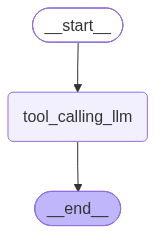

In [16]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)  
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today?


In [21]:
messages = graph.invoke({"messages": HumanMessage(content="What is 4,829 times 7,193?"
)})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 4,829 times 7,193?
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_501e411a-4e2f-4646-b7dd-62e69717e134)
 Call ID: fc_501e411a-4e2f-4646-b7dd-62e69717e134
  Args:
    a: 4829
    b: 7193


In [20]:
messages = graph.invoke({"messages": HumanMessage(content="What is 20 squared?")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 20 squared?
================================== Ai Message ==================================
Tool Calls:
  squared (fc_f4bd8c79-6941-443a-906c-0170ec0fea03)
 Call ID: fc_f4bd8c79-6941-443a-906c-0170ec0fea03
  Args:
    a: 20
